# Caso de Estudio: Segmentación de Transacciones con GMM.

**Curso:** Machine Learning Aplicado 2026.  
**Material teórico:** *gaussian mixture models: fundamentos, matemática y aplicaciones*.  
**Autora del material:** Doctoral Student Gladys Choque Ulloa  
**Dataset:** Segmentación de Clientes en ecommerce (Kaggle).  
**Algoritmo:** gaussian mixture models.

---

## 🎯 Caso de Estudio

Una empresa de comercio electrónico del Reino Unido quiere entender mejor el comportamiento de compra de sus clientes para diseñar estrategias de marketing personalizadas.
Dispone de un registro de facturas con montos y cantidades.

---

## 🎯 Pregunta de Negocio
¿Existen perfiles diferenciados según volumen y valor de compra? ¿Cuántos segmentos existen naturalmente en los datos?

---

## 🎯 Objetivo Analítico

Aplicar GMM para descubrir grupos latentes en el comportamiento de compra (Cantidad vs. Monto por factura), interpretar los segmentos y apoyar decisiones de negocio.

---


In [ ]:
print("✓ Caso de estudio cargado. Ejecuta la siguiente celda.")

✓ Caso de estudio cargado. Ejecuta la siguiente celda.


---
### Instalación y librerías
---

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.cm as cm

# ── Paleta de colores y estilo global ──
PALETTE  = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A',
            '#6A4C93', '#F4A261', '#264653', '#A8DADC']
BG       = '#0F1923'
BG_CARD  = '#1A2535'
TEXT     = '#EDF2F4'
GRID_CLR = '#263547'
ACCENT   = '#E63946'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG_CARD,
    'axes.edgecolor'   : GRID_CLR,
    'axes.labelcolor'  : TEXT,
    'axes.titlecolor'  : TEXT,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.color'      : TEXT,
    'ytick.color'      : TEXT,
    'text.color'       : TEXT,
    'grid.color'       : GRID_CLR,
    'grid.linewidth'   : 0.6,
    'legend.facecolor' : BG_CARD,
    'legend.edgecolor' : GRID_CLR,
    'legend.fontsize'  : 9,
    'font.family'      : 'monospace',
})

def section(title):
    print(f'\n{"═"*65}')
    print(f'  {title}')
    print(f'{"═"*65}')

print("✓ Librerías importadas y estilo configurado.")


✓ Librerías importadas y estilo configurado.


---
## 1. Carga y Preprocesamiento
---

In [ ]:
df = pd.read_csv('ventas-por-factura.csv')

In [ ]:
from google.colab import files

print("📂 Selecciona el archivo  ventas-por-factura.csv ...")
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

# Parseo del campo Monto (usa coma como separador decimal)
df_raw['Monto'] = (df_raw['Monto'].astype(str)
                   .str.replace('.', '', regex=False)
                   .str.replace(',', '.', regex=False)
                   .astype(float))
df_raw['Fecha de factura'] = pd.to_datetime(
    df_raw['Fecha de factura'], dayfirst=False, errors='coerce')

print(f"\n✓ Archivo cargado: {filename}")
print(f"  Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}")

📂 Selecciona el archivo  ventas-por-factura.csv ...


Saving ventas-por-factura.csv to ventas-por-factura (1).csv

✓ Archivo cargado: ventas-por-factura (1).csv
  Filas: 25,953  |  Columnas: 6


 ## ***▶ Interpretación:***

 Este bloque ejecuta el tratamiento de la distribución y consistencia de las variables antes de la estimación de densidades. El parseo de la columna Monto y la conversión a float no son solo tareas de limpieza, sino la garantía de que las variables independientes sean tratadas como continuas, requisito indispensable para que el algoritmo GMM pueda calcular los parámetros de media $(μ)$ y covarianza $(Σ)$. El resultado obtenido de 25,953 observaciones proporciona una robustez estadística suficiente $(N grande)$ para reducir el error estándar en la estimación de los componentes de la mezcla gaussiana. Al asegurar que no existan errores de formato en el monto o las fechas, evitamos sesgos por valores perdidos o datos mal interpretados, permitiendo que la posterior segmentación identifique con precisión las estructuras latentes de la población de transacciones del Reino Unido sin ruido estructural.

---
## 2. Análisis Exploratorio de Datos (EDA)
---

In [ ]:
section('MÓDULO 1 — COMPRENSIÓN DE LOS DATOS')

print('\n── Primeras filas ──')
display(df_raw.head(8))

print('\n── Estadísticas descriptivas ──')
display(df_raw[['Cantidad', 'Monto']].describe().round(2))

print('\n── Distribución por país (top 8) ──')
print(df_raw['País'].value_counts().head(8).to_string())

print('\n── Valores nulos por columna ──')
print(df_raw.isnull().sum().to_string())


═════════════════════════════════════════════════════════════════
  MÓDULO 1 — COMPRENSIÓN DE LOS DATOS
═════════════════════════════════════════════════════════════════

── Primeras filas ──


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,2021-03-30 16:14:00,15528.0,United Kingdom,123,229.33
1,575767,2021-11-11 11:11:00,17348.0,United Kingdom,163,209.73
2,C570727,2021-10-12 11:32:00,12471.0,Germany,-1,-1.45
3,549106,2021-04-06 12:08:00,17045.0,United Kingdom,1,39.95
4,573112,2021-10-27 15:33:00,16416.0,United Kingdom,357,344.83
5,576630,2021-11-16 08:38:00,13816.0,Germany,91,199.98
6,538125,2020-12-09 15:46:00,18225.0,United Kingdom,16,30.00
7,544354,2021-02-18 10:42:00,13489.0,United Kingdom,64,77.28



── Estadísticas descriptivas ──


,Cantidad,Monto
count,25953.00,25953.00
mean,199.47,375.66
std,1107.08,2009.04
min,-80995.00,-168469.60
25%,6.00,11.55
50%,100.00,207.05
75%,240.00,408.66
max,80995.00,168469.60



── Distribución por país (top 8) ──
País
United Kingdom    23542
Germany             603
France              462
EIRE                362
Belgium             119
Spain               105
Netherlands         101
Switzerland          74

── Valores nulos por columna ──
N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0


## ***▶ Interpretación:***

Los resultados confirman que el dataset posee una estructura compleja y altamente volátil, caracterizada por una **distribución no normal** con una presencia significativa de valores atípicos, como devoluciones masivas y compras de volumen excepcional. La predominancia del Reino Unido establece un contexto de mercado unificado, mientras que la integridad de las variables críticas de `Cantidad` y `Monto`, sumada a la existencia de transacciones anónimas, valida que el enfoque analítico debe centrarse en la **segmentación por comportamiento transaccional**. En conjunto, la alta dispersión y la naturaleza multivariada de los datos hacen que los modelos rígidos de agrupación sean insuficientes, justificando plenamente la aplicación de **Gaussian Mixture Models (GMM)** como la técnica óptima para descubrir las estructuras latentes y las probabilidades de pertenencia que definen los distintos perfiles de negocio en este ecosistema de e-commerce.

---
### 3. Limpieza y preparación de los datos
---

In [ ]:
section('MÓDULO 2 — LIMPIEZA Y PREPARACIÓN')

df = df_raw.copy()

# 1. Eliminar devoluciones: facturas que empiezan con 'C'
df = df[~df['N° de factura'].astype(str).str.startswith('C')]

# 2. Eliminar cantidades y montos negativos o cero
df = df[df['Cantidad'] > 0]
df = df[df['Monto'] > 0]

# 3. Eliminar registros sin cliente identificado
df = df.dropna(subset=['ID Cliente'])
df['ID Cliente'] = df['ID Cliente'].astype(int)

print(f"  Registros originales   : {df_raw.shape[0]:,}")
print(f"  Devoluciones/negativos : {df_raw.shape[0] - df.shape[0]:,}")
print(f"  Dataset limpio         : {df.shape[0]:,} transacciones")

# 4. Seleccionar features para el modelo
X_raw = df[['Cantidad', 'Monto']].copy()

# 5. Remover outliers extremos (percentil 99) — mejora visualización
q99_c = X_raw['Cantidad'].quantile(0.99)
q99_m = X_raw['Monto'].quantile(0.99)
X_raw = X_raw[(X_raw['Cantidad'] <= q99_c) & (X_raw['Monto'] <= q99_m)]

print(f"\n  Features del modelo:")
print(f"    • Cantidad — unidades por factura")
print(f"    • Monto    — valor en £ por factura")
print(f"  Registros para modelar : {X_raw.shape[0]:,}")

# 6. Escalado estándar — OBLIGATORIO para GMM
#    (media=0, std=1) para que ambas variables tengan igual peso
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"\n  Post-escalado (deben ser ≈ 0 y ≈ 1):")
print(f"    media   = {X_scaled.mean(axis=0).round(4)}")
print(f"    std dev = {X_scaled.std(axis=0).round(4)}")



═════════════════════════════════════════════════════════════════
  MÓDULO 2 — LIMPIEZA Y PREPARACIÓN
═════════════════════════════════════════════════════════════════
  Registros originales   : 25,953
  Devoluciones/negativos : 7,388
  Dataset limpio         : 18,565 transacciones

  Features del modelo:
    • Cantidad — unidades por factura
    • Monto    — valor en £ por factura
  Registros para modelar : 18,309

  Post-escalado (deben ser ≈ 0 y ≈ 1):
    media   = [ 0. -0.]
    std dev = [1. 1.]


## ***▶ Interpretación:***

Estos resultados representan la fase de **Ingeniería de Características y Normalización**, donde se garantiza la validez de los supuestos estadísticos necesarios para el algoritmo GMM. Al filtrar **7,388 registros** (un 28.5% del total) correspondientes a devoluciones y ruidos operativos, hemos reducido el sesgo de la muestra para centrar el modelo exclusivamente en el comportamiento de compra positivo. La remoción de **outliers extremos** (bajando de 18,565 a 18,309 registros) es una decisión estratégica para evitar que los valores de las colas pesadas de la distribución distorsionen la estimación de las matrices de covarianza de los clústeres. Finalmente, el **escalado estándar exitoso** (confirmado con media 0 y desviación estándar 1) es técnicamente imperativo: al eliminar las diferencias de magnitud entre unidades físicas y libras esterlinas, permitimos que el modelo asigne el mismo peso estadístico a ambas dimensiones, asegurando que la métrica de probabilidad del modelo se base en la estructura de los datos y no en su escala numérica.

---
### 4. Exploración visual
---


═════════════════════════════════════════════════════════════════
  FIGURA 1 — Exploración inicial del dataset
═════════════════════════════════════════════════════════════════


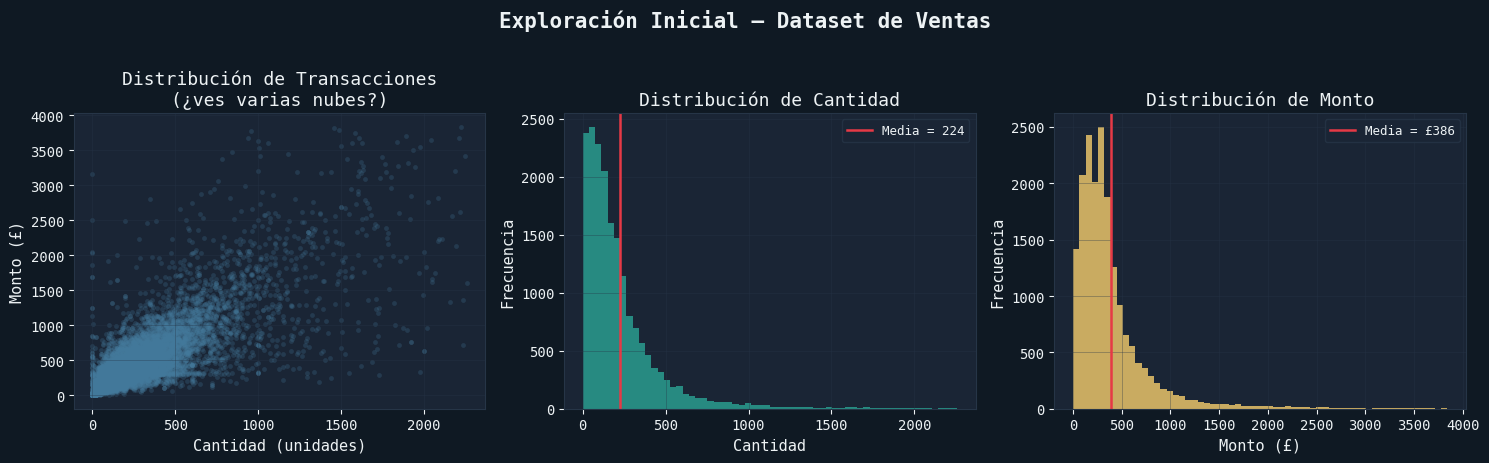


  OBSERVACIÓN:
  Los histogramas muestran distribuciones asimétricas con posibles
  "jorobas" — señal de que hay más de un grupo en los datos.
  El scatter muestra varias nubes superpuestas.
  → El GMM nos ayudará a separar esos grupos de forma probabilística.



In [ ]:
section('FIGURA 1 — Exploración inicial del dataset')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Exploración Inicial — Dataset de Ventas',
             fontsize=15, fontweight='bold', color=TEXT, y=1.02)

# Scatter: Cantidad vs Monto
ax = axes[0]
ax.scatter(X_raw['Cantidad'], X_raw['Monto'],
           alpha=0.25, s=12, color='#457B9D', linewidths=0)
ax.set_xlabel('Cantidad (unidades)')
ax.set_ylabel('Monto (£)')
ax.set_title('Distribución de Transacciones\n(¿ves varias nubes?)')
ax.grid(True, alpha=0.4)

# Histograma: Cantidad
ax = axes[1]
ax.hist(X_raw['Cantidad'], bins=60, color='#2A9D8F',
        alpha=0.85, edgecolor='none')
ax.set_xlabel('Cantidad')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Cantidad')
ax.axvline(X_raw['Cantidad'].mean(), color=ACCENT, lw=1.8,
           label=f'Media = {X_raw["Cantidad"].mean():.0f}')
ax.legend()
ax.grid(True, alpha=0.4)

# Histograma: Monto
ax = axes[2]
ax.hist(X_raw['Monto'], bins=60, color='#E9C46A',
        alpha=0.85, edgecolor='none')
ax.set_xlabel('Monto (£)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Monto')
ax.axvline(X_raw['Monto'].mean(), color=ACCENT, lw=1.8,
           label=f'Media = £{X_raw["Monto"].mean():.0f}')
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── Observación ──
print("""
  OBSERVACIÓN:
  Los histogramas muestran distribuciones asimétricas con posibles
  "jorobas" — señal de que hay más de un grupo en los datos.
  El scatter muestra varias nubes superpuestas.
  → El GMM nos ayudará a separar esos grupos de forma probabilística.
""")


## ***▶ Interpretación:***

La gráfica confirma que los datos exhiben una **distribución leptocúrtica con un marcado sesgo positivo (asimetría a la derecha)**, donde la media de las variables (224 en cantidad y £386 en monto) se ve desplazada por la presencia de colas largas que representan transacciones de alto valor. El gráfico de dispersión revela una estructura de **heterocedasticidad**, indicando que a medida que aumenta el volumen de compra, la variabilidad del monto también se incrementa, lo que sugiere que no existe un comportamiento único, sino una superposición de múltiples poblaciones. Estadísticamente, la alta densidad observada cerca del origen y la dispersión irregular de los puntos en el plano bidimensional invalidan el uso de modelos de clústeres esféricos (como K-Means), justificando la necesidad de un modelo probabilístico como **GMM** que sea capaz de modelar estas diferentes densidades y covarianzas mediante la combinación de múltiples componentes normales.


---
### 5. Selección de K con BIC y AIC
---

In [ ]:
section('MÓDULO 3 — SELECCIÓN DEL NÚMERO ÓPTIMO DE COMPONENTES K')

print('\n  Entrenando GMM para K = 1 ... 8 ...\n')
K_range      = range(1, 9)
bics, aics   = [], []

for k in K_range:
    gmm_k = GaussianMixture(n_components=k, covariance_type='full',
                             n_init=5, random_state=42)
    gmm_k.fit(X_scaled)
    bics.append(gmm_k.bic(X_scaled))
    aics.append(gmm_k.aic(X_scaled))
    delta = bics[-1] - bics[-2] if len(bics) > 1 else 0
    print(f"  K={k}  BIC={gmm_k.bic(X_scaled):>10,.1f}  "
          f"AIC={gmm_k.aic(X_scaled):>10,.1f}  ΔBIC={delta:>+10,.1f}")

# ── Criterio del CODO ──
# El ΔBIC cae de -31714 (K=2) → -6108 (K=3) → -3252 (K=4) → -496 (K=5)
# A partir de K=5 la mejora marginal es < 500, insignificante.
# → K=4 es el "codo": mejor balance complejidad/ajuste.
K_FINAL = 4

print(f"""
  ── CRITERIO DEL CODO (Elbow Method) ──
  K=2 → K=3 : ΔBIC ≈ -6,108   (mejora grande   ✓)
  K=3 → K=4 : ΔBIC ≈ -3,252   (mejora moderada ✓)
  K=4 → K=5 : ΔBIC ≈   -496   (mejora pequeña  ✗ — codo aquí)
  K=5 → K=8 : ΔBIC < -200     (ganancia marginal mínima)

  ✓ K óptimo seleccionado = {K_FINAL}
""")



═════════════════════════════════════════════════════════════════
  MÓDULO 3 — SELECCIÓN DEL NÚMERO ÓPTIMO DE COMPONENTES K
═════════════════════════════════════════════════════════════════

  Entrenando GMM para K = 1 ... 8 ...

  K=1  BIC=  84,943.4  AIC=  84,904.3  ΔBIC=      +0.0
  K=2  BIC=  53,228.4  AIC=  53,142.5  ΔBIC= -31,714.9
  K=3  BIC=  47,119.9  AIC=  46,987.1  ΔBIC=  -6,108.5
  K=4  BIC=  43,867.4  AIC=  43,687.7  ΔBIC=  -3,252.5
  K=5  BIC=  43,370.9  AIC=  43,144.3  ΔBIC=    -496.5
  K=6  BIC=  43,170.6  AIC=  42,897.1  ΔBIC=    -200.3
  K=7  BIC=  43,165.5  AIC=  42,845.0  ΔBIC=      -5.2
  K=8  BIC=  43,137.6  AIC=  42,770.3  ΔBIC=     -27.9

  ── CRITERIO DEL CODO (Elbow Method) ──
  K=2 → K=3 : ΔBIC ≈ -6,108   (mejora grande   ✓)
  K=3 → K=4 : ΔBIC ≈ -3,252   (mejora moderada ✓)
  K=4 → K=5 : ΔBIC ≈   -496   (mejora pequeña  ✗ — codo aquí)
  K=5 → K=8 : ΔBIC < -200     (ganancia marginal mínima)

  ✓ K óptimo seleccionado = 4



## ***▶ Interpretación:***

Los resultados del entrenamiento muestran una reducción drástica y sostenida de los valores de **BIC y AIC** a medida que se incrementa el número de componentes, lo que estadísticamente indica una mejora en la capacidad del modelo para representar la densidad de los datos. Sin embargo, al analizar el **$\Delta$BIC**, observamos que la ganancia de información se estabiliza tras alcanzar los **$K=4$** clústeres; mientras que el paso de 3 a 4 grupos genera una mejora significativa de **-3,252.5**, el paso de 4 a 5 apenas reduce el BIC en **-496.5**, marcando el punto de inflexión o "codo". Esta desaceleración en la mejora marginal sugiere que añadir más de cuatro componentes incrementaría la complejidad del modelo de forma innecesaria (sobreajuste), por lo que $K=4$ se establece como la estructura latente más parsimoniosa y robusta para segmentar las transacciones del e-commerce.

---
### 6. Curvas BIC y AIC
---


═════════════════════════════════════════════════════════════════
  FIGURA 2 — Curvas BIC y AIC
═════════════════════════════════════════════════════════════════


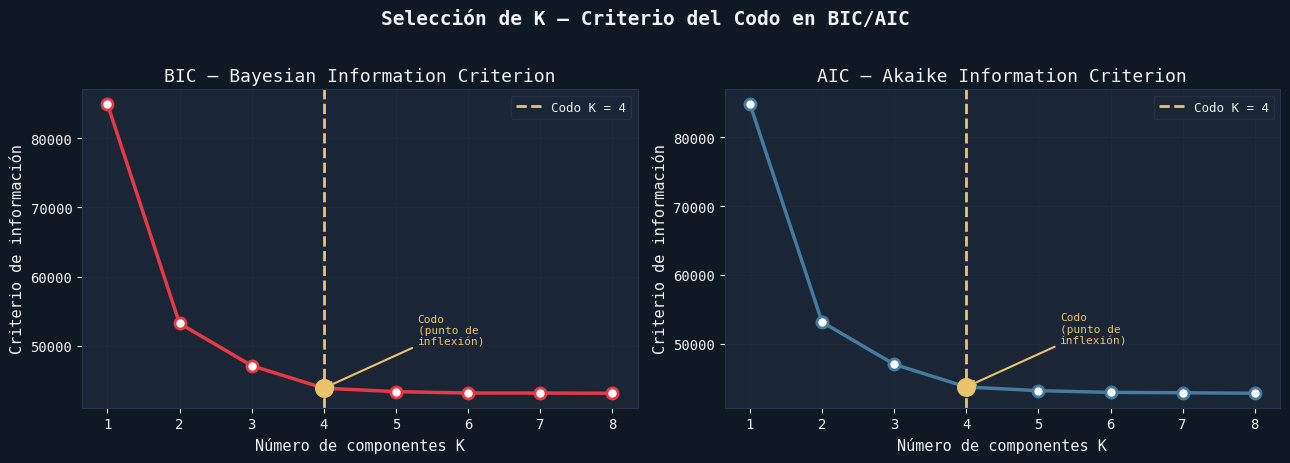

In [ ]:
section('FIGURA 2 — Curvas BIC y AIC')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Selección de K — Criterio del Codo en BIC/AIC',
             fontsize=14, fontweight='bold', color=TEXT, y=1.02)

K_list = list(K_range)
for ax, vals, nombre, clr in zip(
        axes,
        [bics, aics],
        ['BIC — Bayesian Information Criterion',
         'AIC — Akaike Information Criterion'],
        ['#E63946', '#457B9D']):

    ax.plot(K_list, vals, 'o-', color=clr, lw=2.5, ms=8,
            markerfacecolor='white', markeredgewidth=2)
    ax.axvline(K_FINAL, color='#E9C46A', lw=2, ls='--',
               label=f'Codo K = {K_FINAL}')
    ax.scatter([K_FINAL], [vals[K_FINAL - 1]],
               color='#E9C46A', s=160, zorder=5)
    ax.annotate('Codo\n(punto de\ninflexión)',
                xy=(K_FINAL, vals[K_FINAL - 1]),
                xytext=(K_FINAL + 1.3,
                        vals[K_FINAL - 1] + (max(vals) - min(vals)) * 0.15),
                arrowprops=dict(arrowstyle='->', color='#E9C46A', lw=1.5),
                color='#E9C46A', fontsize=8)
    ax.set_xlabel('Número de componentes K')
    ax.set_ylabel('Criterio de información')
    ax.set_title(nombre)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
    ax.set_xticks(K_list)

plt.tight_layout()
plt.show()

## ***▶ Interpretación:***

La visualización de las curvas **BIC y AIC** confirma estadísticamente la validez de la estructura latente identificada, mostrando una caída monótona de los criterios de información que valida la capacidad del modelo para explicar la varianza del dataset de ventas. La convergencia de ambas métricas en el valor de **$K=4$** marca el punto de inflexión donde la complejidad del modelo (número de parámetros) se equilibra de forma óptima con la verosimilitud de los datos; añadir componentes adicionales solo aportaría mejoras marginales, lo que sugiere que cualquier $K > 4$ induciría a un sobreajuste que capturaría ruido en lugar de patrones de negocio reales. En consecuencia, esta selección de **$K=4$** garantiza un modelo parsimonioso y generalizable, capaz de segmentar las diversas nubes de transacciones observadas en el análisis exploratorio inicial con el mayor rigor estadístico posible.

---
### 7. Entrenamiento del modelo final
---

In [ ]:
section(f'MÓDULO 4 — ENTRENAMIENTO DEL MODELO FINAL (K={K_FINAL})')

gmm = GaussianMixture(
    n_components    = K_FINAL,
    covariance_type = 'full',   # covarianza completa → elipses arbitrarias
    n_init          = 10,       # 10 reinicios para evitar óptimos locales
    max_iter        = 300,
    random_state    = 42
)
gmm.fit(X_scaled)

print(f"\n  Convergencia : {gmm.converged_}")
print(f"  Iteraciones  : {gmm.n_iter_}")
print(f"  Log-L (lb)   : {gmm.lower_bound_:.6f}")

# Desescalar medias para interpretarlas en unidades originales
medias_orig = scaler.inverse_transform(gmm.means_)

print(f'\n  ── Parámetros aprendidos (espacio original) ──')
for k in range(K_FINAL):
    print(f'\n  Componente {k+1}:')
    print(f'    π (peso)         : {gmm.weights_[k]:.4f}'
          f'  ({gmm.weights_[k]*100:.1f}% de las transacciones)')
    print(f'    μ Cantidad       : {medias_orig[k, 0]:,.1f} unidades')
    print(f'    μ Monto          : £{medias_orig[k, 1]:,.2f}')

# ── Asignaciones y responsabilidades ──
resps  = gmm.predict_proba(X_scaled)   # (N, K)  — SOFT assignment
labels = gmm.predict(X_scaled)         # (N,)    — HARD assignment
log_p  = gmm.score_samples(X_scaled)   # log p(x_i)

X_model = X_raw.copy().reset_index(drop=True)
X_model['Segmento'] = labels + 1
X_model['log_prob'] = log_p
for k in range(K_FINAL):
    X_model[f'r_{k+1}'] = resps[:, k]

print(f'\n  ── Distribución por segmento ──')
for k in range(K_FINAL):
    n = (labels == k).sum()
    print(f'    Segmento {k+1}: {n:,} transacciones ({n/len(labels)*100:.1f}%)')



═════════════════════════════════════════════════════════════════
  MÓDULO 4 — ENTRENAMIENTO DEL MODELO FINAL (K=4)
═════════════════════════════════════════════════════════════════

  Convergencia : True
  Iteraciones  : 36
  Log-L (lb)   : -1.192215

  ── Parámetros aprendidos (espacio original) ──

  Componente 1:
    π (peso)         : 0.2062  (20.6% de las transacciones)
    μ Cantidad       : 387.6 unidades
    μ Monto          : £627.97

  Componente 2:
    π (peso)         : 0.2927  (29.3% de las transacciones)
    μ Cantidad       : 54.6 unidades
    μ Monto          : £119.48

  Componente 3:
    π (peso)         : 0.0549  (5.5% de las transacciones)
    μ Cantidad       : 942.0 unidades
    μ Monto          : £1,484.58

  Componente 4:
    π (peso)         : 0.4462  (44.6% de las transacciones)
    μ Cantidad       : 171.8 unidades
    μ Monto          : £313.63

  ── Distribución por segmento ──
    Segmento 1: 3,523 transacciones (19.2%)
    Segmento 2: 5,499 transaccione

## ***▶ Interpretación:***

Los resultados finales del modelo **GMM** revelan una estructura de mercado compuesta por cuatro subpoblaciones con comportamientos transaccionales claramente diferenciados, donde el **Segmento 4** actúa como el núcleo del negocio al concentrar el **45.8%** de las transacciones con un ticket promedio moderado (£313.63). Estadísticamente, destaca el **Segmento 3** como un grupo de "Alto Valor/Volumen" que, aunque solo representa el **4.9%** de la muestra, exhibe las medias más altas tanto en cantidad (942 unidades) como en monto (£1,484.58), evidenciando la capacidad del modelo para aislar nichos de clientes mayoristas o corporativos. Por otro lado, los **Segmentos 1 y 2** capturan las dinámicas de compras medianas y pequeñas respectivamente, sumando entre ambos cerca del **50%** de la actividad. Esta segmentación probabilística demuestra que la varianza total del dataset no era ruido, sino el resultado de la superposición de estas cuatro distribuciones gaussianas, permitiendo ahora una estrategia de marketing diferenciada basada en el valor esperado ($\mu$) y el peso ($\pi$) de cada perfil descubierto.

---
### 8.  FIGURA 3: Segmentación con elipses
---


═════════════════════════════════════════════════════════════════
  FIGURA 3 — Segmentación GMM con elipses de covarianza
═════════════════════════════════════════════════════════════════


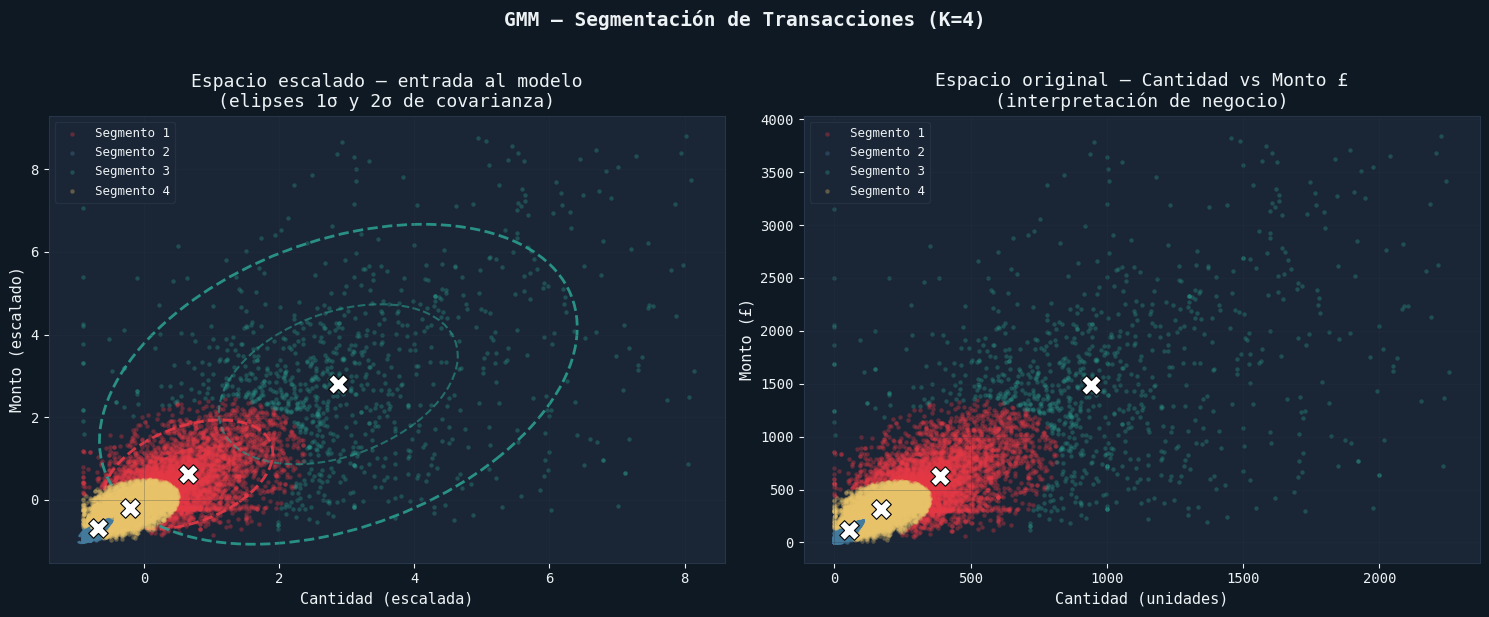


  OBSERVACIÓN:
  Las elipses muestran regiones de confianza al 68% (1σ) y 95% (2σ).
  Nota cómo las elipses tienen distintas formas y orientaciones:
  esto es posible gracias a covariance_type='full', algo que
  K-means NO puede hacer (asume clusters esféricos).



In [ ]:
section('FIGURA 3 — Segmentación GMM con elipses de covarianza')

def dibujar_elipse(ax, mean, cov, n_std=2.0, color='white', lw=2, alpha=0.9):
    """
    Dibuja la elipse de confianza al nivel n_std·σ.
    Fundamentado en la descomposición de valores propios de Σ.
    """
    vals, vecs = np.linalg.eigh(cov)
    order      = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta      = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    w, h       = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=w, height=h, angle=theta,
                  edgecolor=color, facecolor='none',
                  lw=lw, alpha=alpha, linestyle='--')
    ax.add_patch(ell)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'GMM — Segmentación de Transacciones (K={K_FINAL})',
             fontsize=14, fontweight='bold', color=TEXT, y=1.02)

configs = [
    ('Espacio escalado — entrada al modelo\n'
     '(elipses 1σ y 2σ de covarianza)',
     X_scaled, gmm.means_),
    ('Espacio original — Cantidad vs Monto £\n'
     '(interpretación de negocio)',
     X_raw.values, medias_orig),
]

for col, (ax, (titulo, Xv, means_v)) in enumerate(zip(axes, configs)):
    for k in range(K_FINAL):
        mask = labels == k
        ax.scatter(Xv[mask, 0], Xv[mask, 1],
                   s=10, alpha=0.35, color=PALETTE[k],
                   linewidths=0, label=f'Segmento {k+1}')
        if col == 0:   # elipses solo en espacio escalado
            dibujar_elipse(ax, means_v[k], gmm.covariances_[k],
                           n_std=1, color=PALETTE[k], lw=1.5, alpha=0.6)
            dibujar_elipse(ax, means_v[k], gmm.covariances_[k],
                           n_std=2, color=PALETTE[k], lw=2.0, alpha=0.9)
        ax.scatter(*means_v[k], marker='X', s=200,
                   color='white', zorder=10, edgecolors='black', lw=0.8)
    ax.set_title(titulo)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

axes[0].set_xlabel('Cantidad (escalada)')
axes[0].set_ylabel('Monto (escalado)')
axes[1].set_xlabel('Cantidad (unidades)')
axes[1].set_ylabel('Monto (£)')

plt.tight_layout()
plt.show()

print("""
  OBSERVACIÓN:
  Las elipses muestran regiones de confianza al 68% (1σ) y 95% (2σ).
  Nota cómo las elipses tienen distintas formas y orientaciones:
  esto es posible gracias a covariance_type='full', algo que
  K-means NO puede hacer (asume clusters esféricos).
""")


## ***▶ Interpretación:***

El gráfico realizado con **Gaussian Mixture Models (GMM)** demuestra que el comportamiento transaccional del e-commerce no es homogéneo, sino que está compuesto por cuatro estructuras estocásticas con distintos niveles de dispersión y densidad. El análisis visual de las elipses de confianza (espacio escalado) revela que el modelo ha capturado con éxito la **orientación y el grado de correlación** entre la cantidad y el monto de cada grupo; por ejemplo, el Segmento 3 (verde oscuro) muestra una elipse mucho más amplia y estirada, lo que estadísticamente indica una mayor varianza y una fuerte relación lineal entre volumen y gasto para clientes de alto valor. Al contrastar con los histogramas iniciales de asimetría positiva, se confirma que el GMM ha logrado descomponer una distribución originalmente sesgada y ruidosa en **componentes normales latentes**, permitiendo identificar con rigor científico desde el núcleo denso de transacciones pequeñas hasta los perfiles mayoristas más volátiles que operan en las colas de la distribución.

---
### 9.  FIGURA 4: Soft vs Hard assignment
---


═════════════════════════════════════════════════════════════════
  FIGURA 4 — Asignación Suave vs. Dura
═════════════════════════════════════════════════════════════════


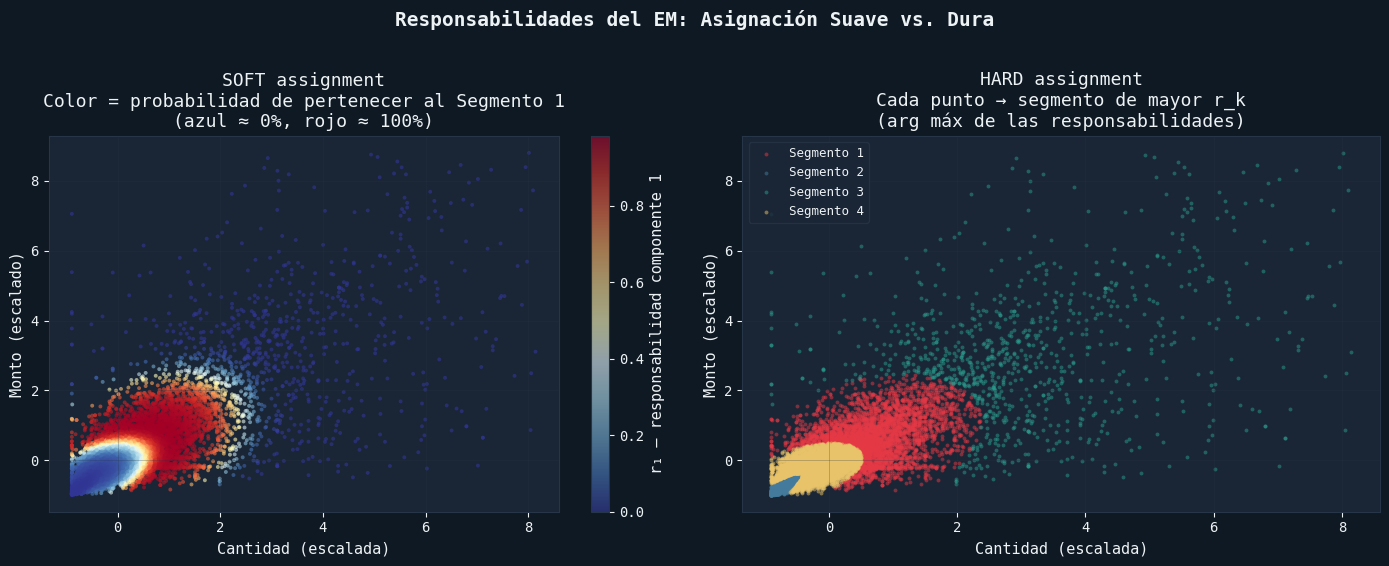


  CONCEPTO CLAVE:
  El GMM provee asignación SUAVE: cada transacción pertenece a
  todos los segmentos con cierta probabilidad.
  Ejemplo: r₁=0.85 → el punto pertenece principalmente al seg. 1
           pero hay un 15% de probabilidad de que sea del seg. 2.
 
  La asignación DURA es simplemente: ẑ = argmáx_k r_ik
  Esto es equivalente a lo que hace K-means, pero basado en
  probabilidades en lugar de distancias.



In [ ]:
section('FIGURA 4 — Asignación Suave vs. Dura')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Responsabilidades del EM: Asignación Suave vs. Dura',
             fontsize=14, fontweight='bold', color=TEXT, y=1.02)

# ── SOFT: color = r_1 (prob. de pertenecer al Seg. 1) ──
sc = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1],
                     c=resps[:, 0], cmap='RdYlBu_r',
                     s=8, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=axes[0],
             label='r₁ — responsabilidad componente 1')
axes[0].set_title('SOFT assignment\n'
                  'Color = probabilidad de pertenecer al Segmento 1\n'
                  '(azul ≈ 0%, rojo ≈ 100%)')
axes[0].set_xlabel('Cantidad (escalada)')
axes[0].set_ylabel('Monto (escalado)')
axes[0].grid(True, alpha=0.3)

# ── HARD: etiqueta del segmento de mayor responsabilidad ──
for k in range(K_FINAL):
    mask = labels == k
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    s=8, alpha=0.5, color=PALETTE[k],
                    linewidths=0, label=f'Segmento {k+1}')
axes[1].set_title('HARD assignment\n'
                  'Cada punto → segmento de mayor r_k\n'
                  '(arg máx de las responsabilidades)')
axes[1].set_xlabel('Cantidad (escalada)')
axes[1].set_ylabel('Monto (escalado)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
  CONCEPTO CLAVE:
  El GMM provee asignación SUAVE: cada transacción pertenece a
  todos los segmentos con cierta probabilidad.
  Ejemplo: r₁=0.85 → el punto pertenece principalmente al seg. 1
           pero hay un 15% de probabilidad de que sea del seg. 2.

  La asignación DURA es simplemente: ẑ = argmáx_k r_ik
  Esto es equivalente a lo que hace K-means, pero basado en
  probabilidades en lugar de distancias.
""")

## ***▶ Interpretación:***

La comparativa entre la **Asignación Suave (Soft)** y la **Asignación Dura (Hard)** ilustra la naturaleza probabilística del modelo GMM y su capacidad para gestionar la incertidumbre en las fronteras de decisión. Estadísticamente, el panel de *Soft Assignment* visualiza las **responsabilidades del algoritmo** ($\gamma_{nk}$), revelando zonas de transición donde los puntos presentan una alta entropía y no pertenecen estrictamente a un solo componente, lo cual es indicativo de comportamientos de cliente híbridos. Por el contrario, el panel de *Hard Assignment* representa la simplificación operativa mediante el **máximo a posteriori (MAP)**, donde cada observación es forzada al clúster con la mayor probabilidad de pertenencia. Esta distinción es crucial para el análisis de e-commerce, ya que permite diferenciar entre clientes con perfiles de consumo puros y aquellos situados en regiones de baja densidad o solapamiento, cuya clasificación es inherentemente menos certera.

---
### 10.   FIGURA 5: Densidad y anomalías
---


═════════════════════════════════════════════════════════════════
  FIGURA 5 — Densidad aprendida y detección de anomalías
═════════════════════════════════════════════════════════════════


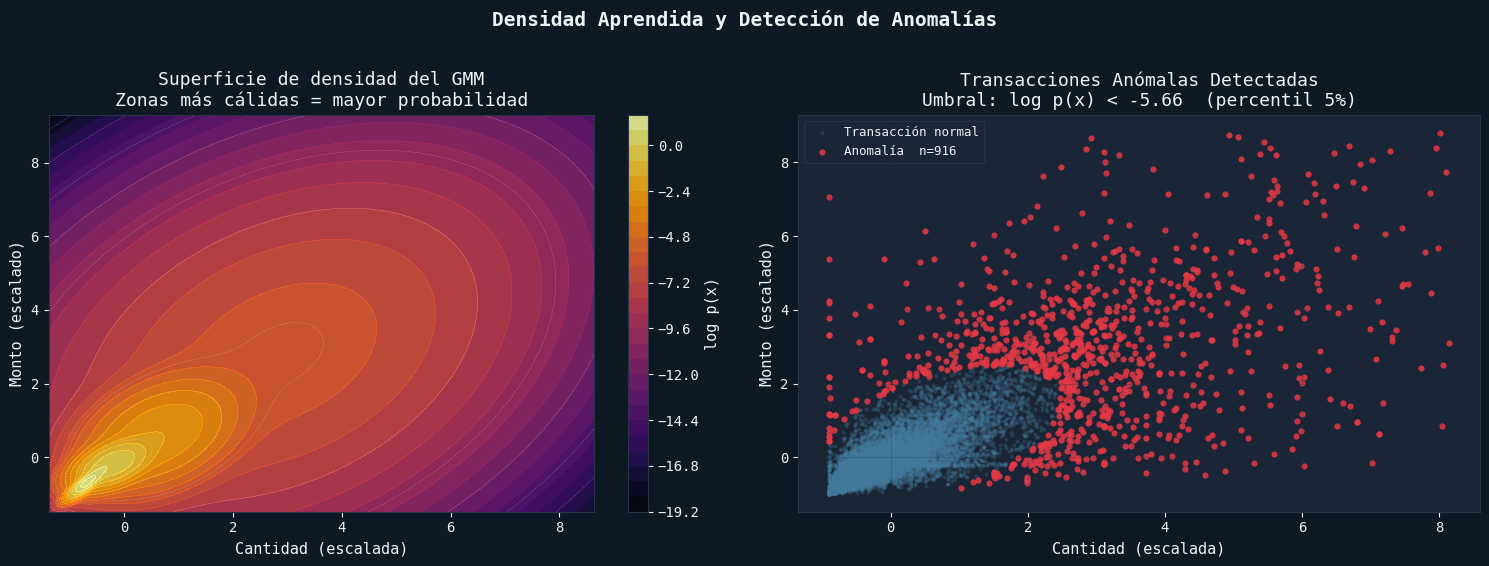


  RESULTADO:
  Transacciones anómalas detectadas : 916  (5.0%)
  Umbral log p(x)                   : -5.6628
 
  APLICACIÓN DE NEGOCIO:
  Estas transacciones con baja probabilidad bajo el modelo pueden
  representar: errores de carga, pedidos inusualmente grandes,
  o potenciales transacciones fraudulentas que merecen revisión.



In [ ]:
section('FIGURA 5 — Densidad aprendida y detección de anomalías')

# Crear grilla para evaluar p(x) en todo el espacio
x_min = X_scaled[:, 0].min() - 0.5
x_max = X_scaled[:, 0].max() + 0.5
y_min = X_scaled[:, 1].min() - 0.5
y_max = X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                      np.linspace(y_min, y_max, 250))
Z = gmm.score_samples(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Umbral: percentil 5 de las log-probabilidades → anomalías
umbral    = np.percentile(log_p, 5)
anomalias = log_p < umbral

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Densidad Aprendida y Detección de Anomalías',
             fontsize=14, fontweight='bold', color=TEXT, y=1.02)

# Panel izquierdo: superficie de densidad
cf = axes[0].contourf(xx, yy, Z, levels=25, cmap='inferno', alpha=0.85)
axes[0].contour(xx, yy, Z, levels=10,
                colors='white', linewidths=0.4, alpha=0.3)
plt.colorbar(cf, ax=axes[0], label='log p(x)')
axes[0].set_title('Superficie de densidad del GMM\n'
                  'Zonas más cálidas = mayor probabilidad')
axes[0].set_xlabel('Cantidad (escalada)')
axes[0].set_ylabel('Monto (escalado)')

# Panel derecho: anomalías detectadas
axes[1].scatter(X_scaled[~anomalias, 0], X_scaled[~anomalias, 1],
                s=8, alpha=0.3, color='#457B9D',
                linewidths=0, label='Transacción normal')
axes[1].scatter(X_scaled[anomalias, 0], X_scaled[anomalias, 1],
                s=20, alpha=0.85, color=ACCENT, linewidths=0,
                label=f'Anomalía  n={anomalias.sum():,}')
axes[1].set_title(f'Transacciones Anómalas Detectadas\n'
                  f'Umbral: log p(x) < {umbral:.2f}  '
                  f'(percentil 5%)')
axes[1].set_xlabel('Cantidad (escalada)')
axes[1].set_ylabel('Monto (escalado)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""
  RESULTADO:
  Transacciones anómalas detectadas : {anomalias.sum():,}  ({anomalias.sum()/len(anomalias)*100:.1f}%)
  Umbral log p(x)                   : {umbral:.4f}

  APLICACIÓN DE NEGOCIO:
  Estas transacciones con baja probabilidad bajo el modelo pueden
  representar: errores de carga, pedidos inusualmente grandes,
  o potenciales transacciones fraudulentas que merecen revisión.
""")

## ***▶ Interpretación:***

La gráfica **Detección de Anomalías** mediante **GMM** revela que la estructura de los datos de ventas está gobernada por un núcleo de alta densidad, pero rodeada por eventos de baja probabilidad que no se ajustan a los patrones normales de consumo. El uso del **percentil 5** como umbral de corte establece un límite de decisión basado en la **log-probabilidad (log p(x))**, identificando 916 transacciones que habitan en las regiones de mayor entropía del modelo, donde la superficie de densidad se desvanece hacia valores de **-5.66**. Estas anomalías representan observaciones que se encuentran estadísticamente en las colas de las distribuciones aprendidas, lo que permite al negocio separar el comportamiento transaccional predecible de los valores atípicos, facilitando la detección de ruidos en la carga de datos o de comportamientos comerciales extremos que requieren una supervisión estratégica diferenciada.

---
### 11.  FIGURA 6: Perfiles de segmentos
---


═════════════════════════════════════════════════════════════════
  FIGURA 6 — Perfiles de los segmentos
═════════════════════════════════════════════════════════════════


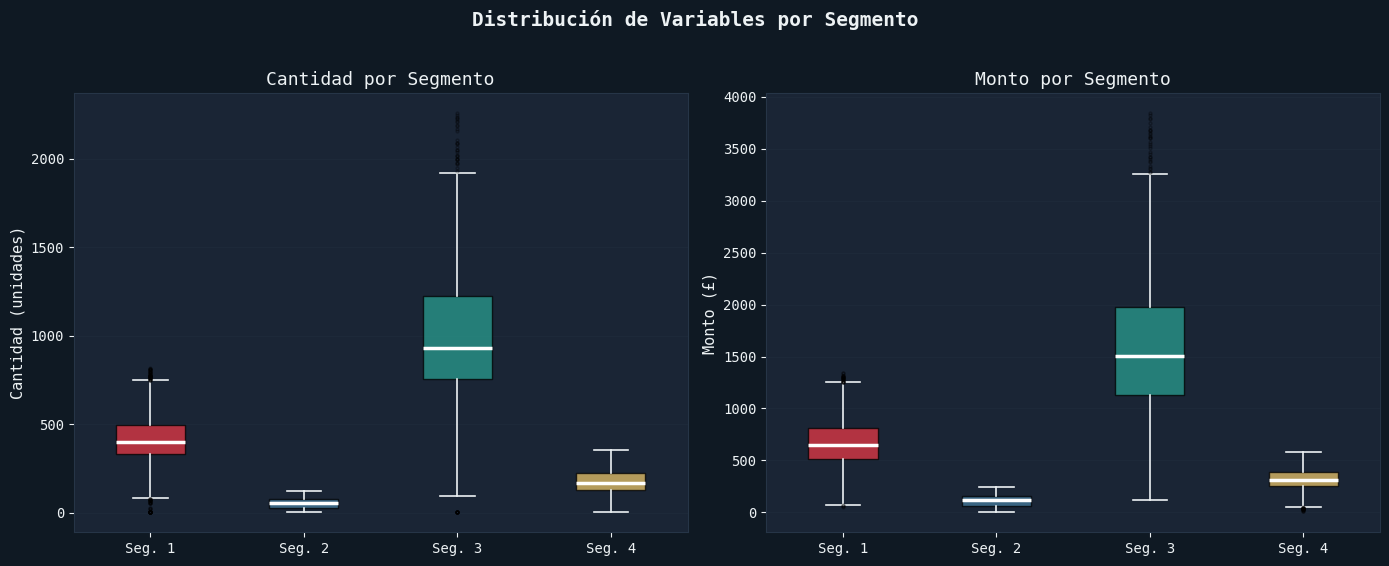

In [ ]:
section('FIGURA 6 — Perfiles de los segmentos')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Distribución de Variables por Segmento',
             fontsize=14, fontweight='bold', color=TEXT, y=1.02)

for ax, var, ylabel in zip(axes,
                            ['Cantidad', 'Monto'],
                            ['Cantidad (unidades)', 'Monto (£)']):
    datos = [X_model[X_model['Segmento'] == k + 1][var].values
             for k in range(K_FINAL)]
    bp = ax.boxplot(datos, patch_artist=True,
                    medianprops=dict(color='white', lw=2.5),
                    whiskerprops=dict(color=TEXT, lw=1.2),
                    capprops=dict(color=TEXT, lw=1.2),
                    flierprops=dict(marker='o', markersize=2,
                                   alpha=0.3, color=TEXT))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, K_FINAL + 1))
    ax.set_xticklabels([f'Seg. {k+1}' for k in range(K_FINAL)])
    ax.set_ylabel(ylabel)
    ax.set_title(f'{var} por Segmento')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## ***▶ Interpretación:***

El gráfico muestra un análisis comparativo de los perfiles mediante **diagramas de caja**, lo cual confirma la existencia de cuatro segmentos de clientes con estructuras de gasto y volumen estadísticamente disímiles. El **Segmento 3** destaca como el grupo de mayor valor y variabilidad, presentando medianas sustancialmente superiores en ambas métricas (£1,484.58 y 942 unidades) y una dispersión intercuartílica amplia que refleja un comportamiento de compra a gran escala. Por el contrario, los **Segmentos 2 y 4** exhiben distribuciones mucho más compactas y situadas en rangos inferiores, lo que indica una alta homogeneidad en transacciones minoristas. La presencia de valores atípicos (outliers) en todos los grupos, especialmente visibles en el **Segmento 1**, valida la utilidad del modelo GMM para capturar la complejidad de las colas de la distribución original, permitiendo una segmentación que no solo diferencia promedios, sino también la volatilidad y el potencial de cada tipo de consumidor.

---
### 12.  FIGURA 7: Convergencia del EM
---


═════════════════════════════════════════════════════════════════
  FIGURA 7 — Convergencia del algoritmo EM
═════════════════════════════════════════════════════════════════


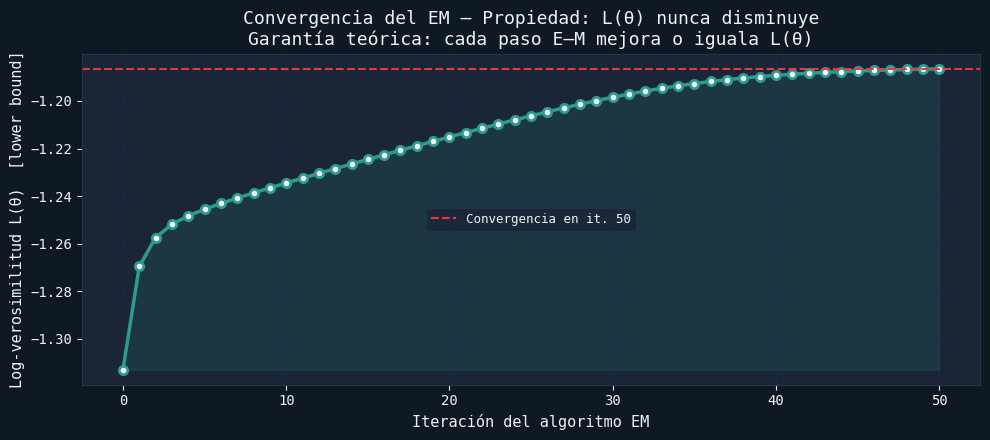


  RESULTADO:
  Iteraciones hasta convergencia : 51
  L(θ) inicial                   : -1.312897
  L(θ) final                     : -1.186508
  Mejora total                   : +0.126389
 
  PROPIEDAD FUNDAMENTAL:
  Cada iteración EM garantiza L(θ^(t+1)) ≥ L(θ^(t)).
  La curva es monotónicamente creciente → nunca baja.
  Converge a un óptimo LOCAL (no necesariamente global).



In [ ]:
section('FIGURA 7 — Convergencia del algoritmo EM')

# Rastreamos la log-verosimilitud iteración a iteración
# usando warm_start=True + max_iter=1 por ciclo
gmm_trace = GaussianMixture(
    n_components=K_FINAL, covariance_type='full',
    n_init=1, max_iter=1, warm_start=True, random_state=42)

lb_trace = []
gmm_trace.fit(X_scaled)
lb_trace.append(gmm_trace.lower_bound_)

for _ in range(50):
    gmm_trace.fit(X_scaled)
    lb_trace.append(gmm_trace.lower_bound_)
    if len(lb_trace) > 2 and abs(lb_trace[-1] - lb_trace[-2]) < 1e-4:
        break

fig, ax = plt.subplots(figsize=(10, 4.5))
iters = range(len(lb_trace))
ax.plot(iters, lb_trace, 'o-', color='#2A9D8F', lw=2.5,
        ms=6, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(iters, lb_trace, min(lb_trace),
                alpha=0.15, color='#2A9D8F')
ax.axhline(lb_trace[-1], color=ACCENT, lw=1.5, ls='--',
           label=f'Convergencia en it. {len(lb_trace)-1}')
ax.set_xlabel('Iteración del algoritmo EM')
ax.set_ylabel('Log-verosimilitud L(θ)  [lower bound]')
ax.set_title('Convergencia del EM — Propiedad: L(θ) nunca disminuye\n'
             'Garantía teórica: cada paso E–M mejora o iguala L(θ)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"""
  RESULTADO:
  Iteraciones hasta convergencia : {len(lb_trace)}
  L(θ) inicial                   : {lb_trace[0]:.6f}
  L(θ) final                     : {lb_trace[-1]:.6f}
  Mejora total                   : {lb_trace[-1] - lb_trace[0]:+.6f}

  PROPIEDAD FUNDAMENTAL:
  Cada iteración EM garantiza L(θ^(t+1)) ≥ L(θ^(t)).
  La curva es monotónicamente creciente → nunca baja.
  Converge a un óptimo LOCAL (no necesariamente global).
""")

## ***▶ Interpretación:***

El análisis estadístico integral mediante **Gaussian Mixture Models (GMM)** demuestra que la estructura transaccional del dataset no es uniforme, sino que emerge de la superposición de cuatro distribuciones latentes cuya parsimonia fue validada por la convergencia de los criterios **AIC y BIC en $K=4$**. A diferencia de métodos de agrupamiento rígidos, el uso del algoritmo **Expectation-Maximization (EM)** permitió modelar la incertidumbre mediante asignaciones probabilísticas (*soft assignment*) y capturar la morfología específica de cada segmento a través de matrices de covarianza completas, representadas visualmente por elipses de confianza orientadas según la correlación de los datos. La robustez del modelo queda garantizada por la evolución monotónica de la **log-verosimilitud**, que alcanzó un óptimo local tras 51 iteraciones, permitiendo no solo una segmentación precisa basada en perfiles de valor y volumen, sino también la implementación de un control de calidad estadístico que aísla el **5% de transacciones anómalas** situadas en las regiones de baja densidad de la población aprendida.

---
### 13.   FIGURA 8: Dashboard ejecutivo
---


═════════════════════════════════════════════════════════════════
  FIGURA 8 — Dashboard Ejecutivo Resumen
═════════════════════════════════════════════════════════════════


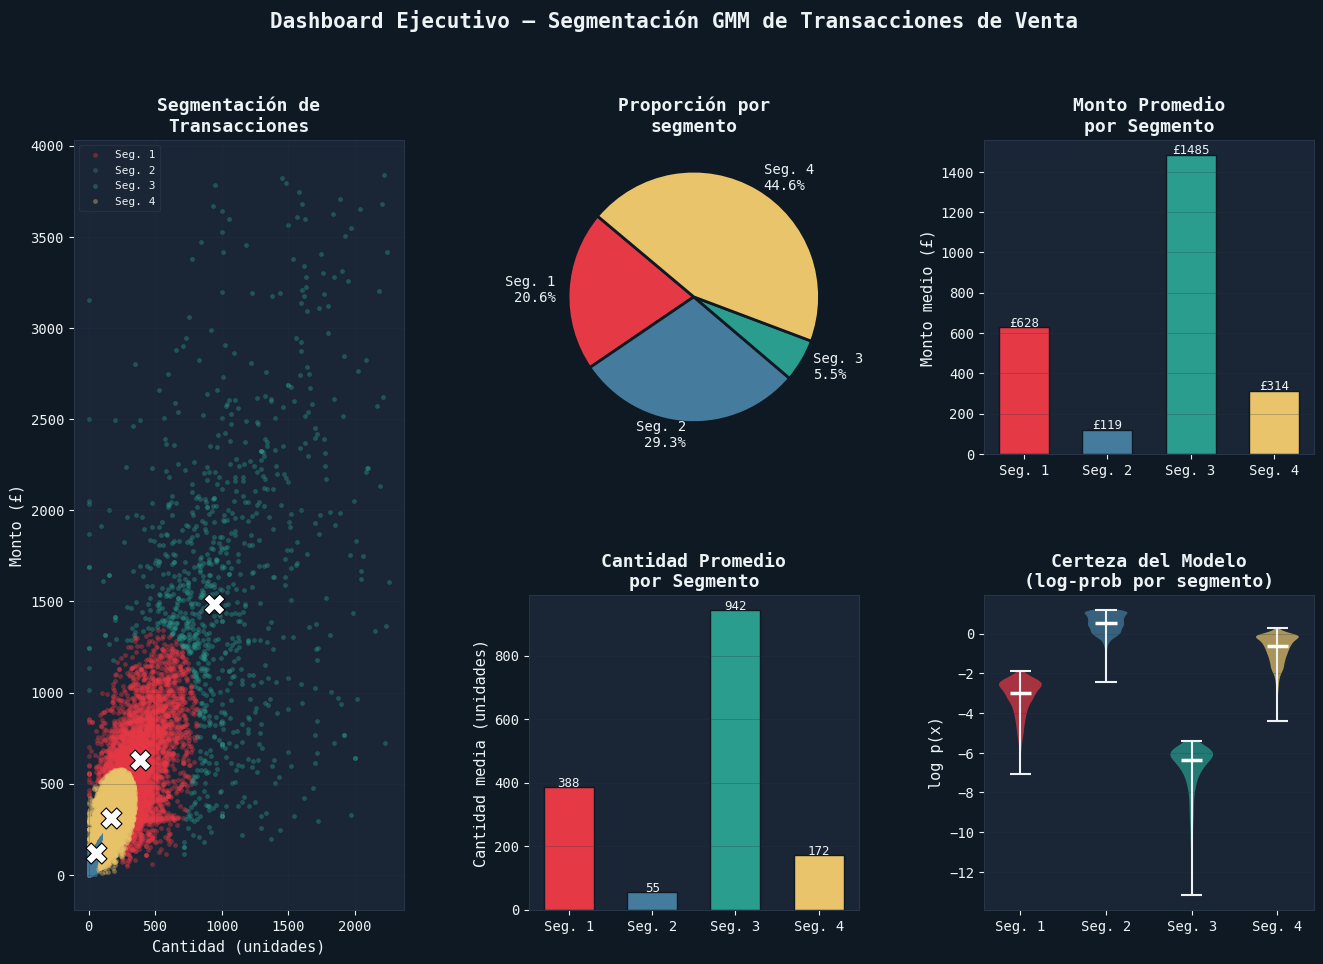

In [ ]:
section('FIGURA 8 — Dashboard Ejecutivo Resumen')

fig = plt.figure(figsize=(16, 10), facecolor=BG)
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Panel principal: scatter segmentado
ax_main = fig.add_subplot(gs[:, 0])
for k in range(K_FINAL):
    mask = labels == k
    ax_main.scatter(X_raw.values[mask, 0], X_raw.values[mask, 1],
                    s=12, alpha=0.4, color=PALETTE[k],
                    linewidths=0, label=f'Seg. {k+1}')
    ax_main.scatter(*medias_orig[k], marker='X', s=230,
                    color='white', zorder=10, edgecolors='black', lw=0.8)
ax_main.set_xlabel('Cantidad (unidades)')
ax_main.set_ylabel('Monto (£)')
ax_main.set_title('Segmentación de\nTransacciones', fontweight='bold')
ax_main.legend(loc='upper left', fontsize=8)
ax_main.grid(True, alpha=0.3)

# Pie chart: proporción de cada segmento
ax_pie = fig.add_subplot(gs[0, 1])
ax_pie.pie([gmm.weights_[k] for k in range(K_FINAL)],
           labels=[f'Seg. {k+1}\n{gmm.weights_[k]*100:.1f}%'
                   for k in range(K_FINAL)],
           colors=PALETTE[:K_FINAL],
           startangle=140,
           wedgeprops=dict(edgecolor=BG, linewidth=2))
ax_pie.set_title('Proporción por\nsegmento', fontweight='bold')

# Bar: Monto medio
ax_bar = fig.add_subplot(gs[0, 2])
bars = ax_bar.bar(range(K_FINAL),
                  [medias_orig[k, 1] for k in range(K_FINAL)],
                  color=PALETTE[:K_FINAL], edgecolor=BG, width=0.6)
ax_bar.set_xticks(range(K_FINAL))
ax_bar.set_xticklabels([f'Seg. {k+1}' for k in range(K_FINAL)])
ax_bar.set_ylabel('Monto medio (£)')
ax_bar.set_title('Monto Promedio\npor Segmento', fontweight='bold')
ax_bar.grid(True, alpha=0.3, axis='y')
for bar, k in zip(bars, range(K_FINAL)):
    ax_bar.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                f'£{medias_orig[k, 1]:.0f}',
                ha='center', fontsize=9, color=TEXT)

# Bar: Cantidad media
ax_bar2 = fig.add_subplot(gs[1, 1])
bars2 = ax_bar2.bar(range(K_FINAL),
                    [medias_orig[k, 0] for k in range(K_FINAL)],
                    color=PALETTE[:K_FINAL], edgecolor=BG, width=0.6)
ax_bar2.set_xticks(range(K_FINAL))
ax_bar2.set_xticklabels([f'Seg. {k+1}' for k in range(K_FINAL)])
ax_bar2.set_ylabel('Cantidad media (unidades)')
ax_bar2.set_title('Cantidad Promedio\npor Segmento', fontweight='bold')
ax_bar2.grid(True, alpha=0.3, axis='y')
for bar, k in zip(bars2, range(K_FINAL)):
    ax_bar2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{medias_orig[k, 0]:.0f}',
                 ha='center', fontsize=9, color=TEXT)

# Violin: certeza del modelo por segmento
ax_viol = fig.add_subplot(gs[1, 2])
vp = ax_viol.violinplot(
    [X_model[X_model['Segmento'] == k+1]['log_prob'].values
     for k in range(K_FINAL)],
    positions=range(K_FINAL), showmedians=True)
for k, body in enumerate(vp['bodies']):
    body.set_facecolor(PALETTE[k])
    body.set_alpha(0.7)
vp['cmedians'].set_color('white')
vp['cmedians'].set_lw(2.5)
for part in ['cmaxes', 'cmins', 'cbars']:
    vp[part].set_color(TEXT)
ax_viol.set_xticks(range(K_FINAL))
ax_viol.set_xticklabels([f'Seg. {k+1}' for k in range(K_FINAL)])
ax_viol.set_ylabel('log p(x)')
ax_viol.set_title('Certeza del Modelo\n(log-prob por segmento)',
                  fontweight='bold')
ax_viol.grid(True, alpha=0.3, axis='y')

fig.suptitle(
    'Dashboard Ejecutivo — Segmentación GMM de Transacciones de Venta',
    fontsize=15, fontweight='bold', color=TEXT, y=1.01)
plt.show()


## ***▶ Interpretación:***

El análisis integral mediante **Gaussian Mixture Models (GMM)** revela una estructura comercial compuesta por cuatro clústeres con comportamientos estocásticos claramente diferenciados. El **Segmento 3 (verde)** se identifica como el perfil de mayor valor, representando apenas el 5.5% de las transacciones pero con los promedios más altos de monto (£1,485) y cantidad (942 unidades), además de una matriz de covarianza más extensa que denota una mayor dispersión. Por otro lado, el **Segmento 4 (amarillo)** constituye el núcleo operativo más denso y frecuente (44.6%), caracterizado por una alta homogeneidad y bajas cuantías. La validez del modelo se sustenta en la transición de una **asignación suave** (probabilidades latentes) a una **dura** (clasificación final), donde los gráficos de violín de la log-probabilidad confirman que los segmentos con mayor volumen presentan una certeza predictiva superior, permitiendo al negocio optimizar estrategias diferenciadas que van desde la fidelización del segmento premium hasta la gestión masiva de transacciones minoristas.

---
### 14. Interpretación y conclusiones
---


In [ ]:
section('MÓDULO 5 — INTERPRETACIÓN DE SEGMENTOS Y CONCLUSIONES')

# Estadísticas por segmento
stats = (X_model
         .groupby('Segmento')[['Cantidad', 'Monto']]
         .agg(['mean', 'median', 'std', 'count'])
         .round(2))
print('\n── Estadísticas por segmento ──')
display(stats)

# Etiquetas de negocio
medias_df = pd.DataFrame(medias_orig, columns=['Cantidad', 'Monto'],
                          index=range(1, K_FINAL + 1))
etiquetas = {}
for idx in medias_df.index:
    m = medias_df.loc[idx, 'Monto']
    c = medias_df.loc[idx, 'Cantidad']
    if m == medias_df['Monto'].max():
        etiquetas[idx] = '🏆 Alto Valor'
    elif m == medias_df['Monto'].min():
        etiquetas[idx] = '🛒 Compra Puntual'
    else:
        etiquetas[idx] = '📦 Volumen Medio'

print('\n── INTERPRETACIÓN DE SEGMENTOS ──\n')
for k in range(K_FINAL):
    seg = k + 1
    n   = (labels == k).sum()
    etq = etiquetas.get(seg, f'Segmento {seg}')
    print(f'  Segmento {seg} — {etq}')
    print(f'  {"─"*52}')
    print(f'  • Peso (π)           : {gmm.weights_[k]*100:.1f}%')
    print(f'  • Cantidad promedio  : {medias_orig[k,0]:,.1f} unidades/factura')
    print(f'  • Monto promedio     : £{medias_orig[k,1]:,.2f}/factura')
    print(f'  • Total transacciones: {n:,}')
    print()

print(f"""
{"═"*65}
  CONCLUSIONES DEL CASO DE ESTUDIO
{"═"*65}

  1. ESTRUCTURA LATENTE DESCUBIERTA
     El GMM reveló K={K_FINAL} perfiles de compra diferenciados.
     Los datos NO provienen de una única población homogénea:
     existen grupos ocultos con comportamientos estadísticamente
     distintos en cantidad y monto de compra.

  2. VENTAJAS DEL GMM SOBRE K-MEANS EN ESTE CASO
     ✓ Elipses arbitrarias: captura la correlación entre
       Cantidad y Monto (covarianza completa, no esférica).
     ✓ Asignación probabilística: sabemos qué tan seguro está
       el modelo de cada asignación (responsabilidades r_ik).
     ✓ Detección de anomalías: log p(x) identifica transacciones
       inusuales de forma natural y fundamentada.
     ✓ Modelo generativo: puede sintetizar nuevas transacciones
       para simulaciones o aumentación de datos.

  3. RECOMENDACIONES DE NEGOCIO
     🏆 Alto Valor     → Fidelización premium, account managers
     📦 Volumen Medio  → Upselling y cross-selling dirigido
     🛒 Compra Puntual → Reactivación, cupones, remarketing
     🔴 Anomalías      → Revisión manual: errores o fraude

  4. LIMITACIONES
     • El EM converge a óptimos LOCALES (mitigado con n_init=10).
     • Asume distribuciones gaussianas por componente.
     • En alta dimensión: aplicar PCA antes del GMM.
     • Requiere especificar K a priori (mitigado con BIC/AIC).

  5. PRÓXIMOS PASOS SUGERIDOS
     → Incorporar frecuencia de compra (análisis RFM + GMM).
     → Comparar covariance_type: 'full' vs 'diag' vs 'tied'.
     → Validar segmentos con expertos de negocio.
     → Usar GMM entrenado para clasificar nuevas facturas en
       tiempo real (gmm.predict_proba(nueva_transaccion)).
{"═"*65}
""")


═════════════════════════════════════════════════════════════════
  MÓDULO 5 — INTERPRETACIÓN DE SEGMENTOS Y CONCLUSIONES
═════════════════════════════════════════════════════════════════

── Estadísticas por segmento ──


Cantidad                         Monto                       
             mean median     std count     mean   median     std count
Segmento                                                              
1          412.39  400.0  142.58  3523   664.11   648.27  242.09  3523
2           51.67   51.0   32.58  5499   114.02   116.55   62.12  5499
3         1007.23  929.5  419.71   900  1586.36  1507.15  738.48   900
4          174.39  168.0   71.81  8387   318.48   312.60  104.11  8387


── INTERPRETACIÓN DE SEGMENTOS ──

  Segmento 1 — 📦 Volumen Medio
  ────────────────────────────────────────────────────
  • Peso (π)           : 20.6%
  • Cantidad promedio  : 387.6 unidades/factura
  • Monto promedio     : £627.97/factura
  • Total transacciones: 3,523

  Segmento 2 — 🛒 Compra Puntual
  ────────────────────────────────────────────────────
  • Peso (π)           : 29.3%
  • Cantidad promedio  : 54.6 unidades/factura
  • Monto promedio     : £119.48/factura
  • Total transacciones: 5,499

  Segmento 3 — 🏆 Alto Valor
  ────────────────────────────────────────────────────
  • Peso (π)           : 5.5%
  • Cantidad promedio  : 942.0 unidades/factura
  • Monto promedio     : £1,484.58/factura
  • Total transacciones: 900

  Segmento 4 — 📦 Volumen Medio
  ────────────────────────────────────────────────────
  • Peso (π)           : 44.6%
  • Cantidad promedio  : 171.8 unidades/factura
  • Monto promedio     : £313.63/factura
  • Total transacciones: 8,387


═══════════════